# 01 · Tiny Shakespeare baseline

目标：验证 `数据 → GPT forward → loss → backward → optimizer → checkpoint → sampling` 完整链路。

说明：本 notebook **自包含**模型与训练代码，不依赖把 `.py` 写到磁盘；唯一外部文件是公开语料 `tinyshakespeare.txt`。

实验顺序：

1. 确认 Colab GPU 与工作目录。
2. 定义数据 / 模型 / 训练代码，下载语料。
3. 在固定 batch 上过拟合，排除训练链路错误。
4. 运行 baseline 并观察 train/val loss。
5. 使用固定 prompt 采样。
6. 重新加载 checkpoint，确认产物可恢复。

In [1]:
import json
import math
import os
import platform

import random
import subprocess
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

print('python:', platform.python_version())
print('torch:', torch.__version__)
print('cwd:', Path.cwd())
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
    subprocess.run(['nvidia-smi'], check=False)

python: 3.12.13
torch: 2.11.0+cu128
cwd: /content
cuda available: True
gpu: NVIDIA A100-SXM4-40GB


In [2]:
# 只用于放语料 / checkpoint / 指标；代码都在本 notebook 的 cells 里
if Path('/content').exists():
    STAGE_DIR = Path('/content/03-nanogpt')
else:
    here = Path.cwd().resolve()
    STAGE_DIR = here if here.name == '03-nanogpt' else here.parent if (here.parent / 'model.py').exists() else here / '03-nanogpt'

STAGE_DIR.mkdir(parents=True, exist_ok=True)
(STAGE_DIR / 'data').mkdir(exist_ok=True)
(STAGE_DIR / 'runs').mkdir(exist_ok=True)
(STAGE_DIR / 'configs').mkdir(exist_ok=True)
os.chdir(STAGE_DIR)
print('stage dir:', STAGE_DIR)

stage dir: /content/03-nanogpt


## 数据工具

字符级 tokenizer；输入 `x` 与目标 `y` 相差一个字符。

In [3]:
from dataclasses import dataclass
from pathlib import Path
from urllib.request import urlopen

import torch


TINY_SHAKESPEARE_URL = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)


@dataclass(frozen=True)
class CharTokenizer:
    chars: tuple[str, ...]

    @classmethod
    def from_text(cls, text: str) -> "CharTokenizer":
        if not text:
            raise ValueError("cannot build a tokenizer from empty text")
        return cls(tuple(sorted(set(text))))

    @property
    def vocab_size(self) -> int:
        return len(self.chars)

    def encode(self, text: str) -> list[int]:
        stoi = {char: index for index, char in enumerate(self.chars)}
        try:
            return [stoi[char] for char in text]
        except KeyError as error:
            raise ValueError(f"unknown character: {error.args[0]!r}") from error

    def decode(self, token_ids: list[int]) -> str:
        try:
            return "".join(self.chars[token_id] for token_id in token_ids)
        except IndexError as error:
            raise ValueError("token id is outside the tokenizer vocabulary") from error


@dataclass(frozen=True)
class TextData:
    train: torch.Tensor
    val: torch.Tensor
    tokenizer: CharTokenizer


def download_tiny_shakespeare(destination: Path) -> Path:
    """Download the small public corpus once and return its local path."""
    destination = Path(destination)
    if destination.exists():
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    with urlopen(TINY_SHAKESPEARE_URL, timeout=30) as response:
        destination.write_bytes(response.read())
    return destination


def load_text_data(path: Path, train_fraction: float = 0.9) -> TextData:
    if not 0.0 < train_fraction < 1.0:
        raise ValueError("train_fraction must be between 0 and 1")

    text = Path(path).read_text(encoding="utf-8")
    tokenizer = CharTokenizer.from_text(text)
    encoded = torch.tensor(tokenizer.encode(text), dtype=torch.long)
    split_index = int(len(encoded) * train_fraction)
    if split_index < 2 or len(encoded) - split_index < 2:
        raise ValueError("text is too short for a train/validation split")
    return TextData(encoded[:split_index], encoded[split_index:], tokenizer)


def get_batch(
    tokens: torch.Tensor,
    *,
    batch_size: int,
    block_size: int,
    device: torch.device,
    generator: torch.Generator | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    if len(tokens) <= block_size:
        raise ValueError("token sequence must be longer than block_size")

    starts = torch.randint(len(tokens) - block_size, (batch_size,), generator=generator)
    x = torch.stack([tokens[start : start + block_size] for start in starts])
    y = torch.stack([tokens[start + 1 : start + block_size + 1] for start in starts])
    return x.to(device), y.to(device)

## 模型

最小 GPT：causal self-attention、MLP、Transformer block、generate。

In [4]:
import math
from dataclasses import asdict, dataclass

import torch
from torch import nn
from torch.nn import functional as F


@dataclass(frozen=True)
class GPTConfig:
    vocab_size: int
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.0
    bias: bool = True

    def __post_init__(self) -> None:
        if self.n_embd % self.n_head != 0:
            raise ValueError("n_embd must be divisible by n_head")
        if min(self.vocab_size, self.block_size, self.n_layer, self.n_head, self.n_embd) <= 0:
            raise ValueError("model dimensions must be positive")

    def to_dict(self) -> dict[str, int | float | bool]:
        return asdict(self)


class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.block_size, config.block_size, dtype=torch.bool)).view(
                1, 1, config.block_size, config.block_size
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, channels = x.shape
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        head_size = channels // self.n_head
        q = q.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)
        k = k.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)
        v = v.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)

        attention = (q @ k.transpose(-2, -1)) / math.sqrt(head_size)
        attention = attention.masked_fill(
            ~self.causal_mask[:, :, :sequence_length, :sequence_length], float("-inf")
        )
        attention = F.softmax(attention, dim=-1)
        attention = F.dropout(attention, p=self.dropout, training=self.training)
        y = attention @ v
        y = y.transpose(1, 2).contiguous().view(batch_size, sequence_length, channels)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        return x + self.mlp(self.ln_2(x))


class GPT(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(
            {
                "wte": nn.Embedding(config.vocab_size, config.n_embd),
                "wpe": nn.Embedding(config.block_size, config.n_embd),
                "drop": nn.Dropout(config.dropout),
                "h": nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                "ln_f": nn.LayerNorm(config.n_embd, bias=config.bias),
            }
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for name, parameter in self.named_parameters():
            if name.endswith("c_proj.weight"):
                nn.init.normal_(parameter, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def num_parameters(self) -> int:
        return sum(parameter.numel() for parameter in self.parameters())

    def forward(
        self, idx: torch.Tensor, targets: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        _, sequence_length = idx.shape
        if sequence_length > self.config.block_size:
            raise ValueError(
                f"sequence length {sequence_length} exceeds block_size {self.config.block_size}"
            )

        positions = torch.arange(sequence_length, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(positions))
        for block in self.transformer.h:
            x = block(x)
        logits = self.lm_head(self.transformer.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        *,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive")
        if top_k is not None and top_k <= 0:
            raise ValueError("top_k must be positive when provided")
        for _ in range(max_new_tokens):
            idx_context = idx[:, -self.config.block_size :]
            logits, _ = self(idx_context)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                threshold = torch.topk(logits, k).values[:, [-1]]
                logits = logits.masked_fill(logits < threshold, float("-inf"))
            probabilities = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)
        return idx

## 训练循环

In [5]:
import json
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch



@dataclass(frozen=True)
class TrainConfig:
    data_path: str = "data/tinyshakespeare.txt"
    run_dir: str = "runs/baseline"
    seed: int = 42
    batch_size: int = 32
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.0
    learning_rate: float = 3e-4
    max_iters: int = 2_000
    eval_interval: int = 200
    eval_iters: int = 50
    log_interval: int = 20
    device: str = "auto"


def resolve_device(requested: str) -> torch.device:
    if requested != "auto":
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


def synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)


@torch.no_grad()
def estimate_loss(
    model: GPT,
    data: TextData,
    config: TrainConfig,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    result: dict[str, float] = {}
    eval_generator = torch.Generator().manual_seed(config.seed + 1)
    for split, tokens in (("train", data.train), ("val", data.val)):
        losses = torch.zeros(config.eval_iters)
        for step in range(config.eval_iters):
            x, y = get_batch(
                tokens,
                batch_size=config.batch_size,
                block_size=config.block_size,
                device=device,
                generator=eval_generator,
            )
            _, loss = model(x, y)
            assert loss is not None
            losses[step] = loss.detach().cpu()
        result[split] = losses.mean().item()
    model.train()
    return result


def save_checkpoint(
    path: Path,
    model: GPT,
    optimizer: torch.optim.Optimizer,
    config: TrainConfig,
    tokenizer_chars: tuple[str, ...],
    step: int,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "train_config": asdict(config),
            "model_config": model.config.to_dict(),
            "tokenizer_chars": tokenizer_chars,
            "step": step,
        },
        path,
    )


def load_checkpoint(
    path: Path, device: torch.device
) -> tuple[GPT, dict[str, Any], torch.optim.Optimizer]:
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model = GPT(GPTConfig(**checkpoint["model_config"])).to(device)
    model.load_state_dict(checkpoint["model"])
    train_config = TrainConfig(**checkpoint["train_config"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=train_config.learning_rate)
    optimizer.load_state_dict(checkpoint["optimizer"])
    return model, checkpoint, optimizer


def run_experiment(config: TrainConfig) -> dict[str, Any]:
    set_seed(config.seed)
    device = resolve_device(config.device)
    data_path = Path(config.data_path)
    download_tiny_shakespeare(data_path)
    data = load_text_data(data_path)

    model_config = GPTConfig(
        vocab_size=data.tokenizer.vocab_size,
        block_size=config.block_size,
        n_layer=config.n_layer,
        n_head=config.n_head,
        n_embd=config.n_embd,
        dropout=config.dropout,
    )
    model = GPT(model_config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
    run_dir = Path(config.run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    history: list[dict[str, float | int]] = []
    started_at = time.perf_counter()
    training_seconds = 0.0
    train_generator = torch.Generator().manual_seed(config.seed)

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    print(f"device={device} parameters={model.num_parameters():,}")
    model.train()
    for step in range(config.max_iters + 1):
        if step % config.eval_interval == 0 or step == config.max_iters:
            losses = estimate_loss(model, data, config, device)
            elapsed = time.perf_counter() - started_at
            record: dict[str, float | int] = {
                "step": step,
                "train_loss": losses["train"],
                "val_loss": losses["val"],
                "elapsed_seconds": elapsed,
                "tokens_per_second": (
                    step * config.batch_size * config.block_size / training_seconds
                    if training_seconds > 0
                    else 0.0
                ),
            }
            history.append(record)
            print(
                f"step={step:5d} train={losses['train']:.4f} "
                f"val={losses['val']:.4f} elapsed={elapsed:.1f}s"
            )
        if step == config.max_iters:
            break

        x, y = get_batch(
            data.train,
            batch_size=config.batch_size,
            block_size=config.block_size,
            device=device,
            generator=train_generator,
        )
        synchronize(device)
        train_step_started_at = time.perf_counter()
        _, loss = model(x, y)
        assert loss is not None
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        synchronize(device)
        training_seconds += time.perf_counter() - train_step_started_at
        if step % config.log_interval == 0:
            print(f"train step={step:5d} batch_loss={loss.item():.4f}")

    checkpoint_path = run_dir / "checkpoint.pt"
    save_checkpoint(
        checkpoint_path,
        model,
        optimizer,
        config,
        data.tokenizer.chars,
        config.max_iters,
    )
    metrics = {
        "config": asdict(config),
        "model_config": model_config.to_dict(),
        "parameters": model.num_parameters(),
        "device": str(device),
        "training_tokens": config.max_iters * config.batch_size * config.block_size,
        "training_seconds": training_seconds,
        "tokens_per_second": (
            config.max_iters * config.batch_size * config.block_size / training_seconds
            if training_seconds > 0
            else 0.0
        ),
        "max_gpu_memory_mb": (
            torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == "cuda" else None
        ),
        "history": history,
        "checkpoint": str(checkpoint_path),
    }
    (run_dir / "metrics.json").write_text(
        json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    return {**metrics, "model": model, "data": data}

## 加载语料

语料下载到 `data/tinyshakespeare.txt`（公开 URL，与私有仓库无关）。

In [6]:
data_path = download_tiny_shakespeare(STAGE_DIR / 'data' / 'tinyshakespeare.txt')
text_data = load_text_data(data_path)
device = resolve_device('auto')
print('device:', device)
print('vocab size:', text_data.tokenizer.vocab_size)
print('train tokens:', len(text_data.train), 'val tokens:', len(text_data.val))
print('characters:', ''.join(text_data.tokenizer.chars))

device: cuda
vocab size: 65
train tokens: 1003854 val tokens: 111540
characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## 诊断：固定 batch 过拟合

预测：如果模型、loss 和反向传播链路正确，重复训练同一个小 batch 时 loss 应快速下降。这个实验不衡量泛化。

loss: 4.2077 → 0.0104


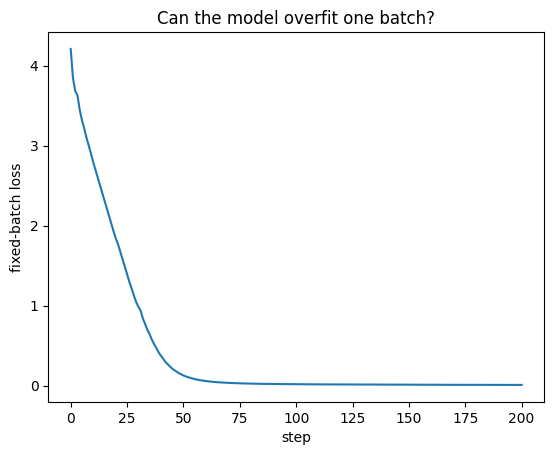

In [7]:
set_seed(42)
diagnostic_config = GPTConfig(
    vocab_size=text_data.tokenizer.vocab_size,
    block_size=32,
    n_layer=2,
    n_head=2,
    n_embd=64,
)
diagnostic_model = GPT(diagnostic_config).to(device)
optimizer = torch.optim.AdamW(diagnostic_model.parameters(), lr=3e-3)
x_fixed, y_fixed = get_batch(
    text_data.train, batch_size=8, block_size=32, device=device
)
diagnostic_losses = []
for step in range(201):
    _, loss = diagnostic_model(x_fixed, y_fixed)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    diagnostic_losses.append(loss.item())

print(f'loss: {diagnostic_losses[0]:.4f} → {diagnostic_losses[-1]:.4f}')
plt.plot(diagnostic_losses)
plt.xlabel('step')
plt.ylabel('fixed-batch loss')
plt.title('Can the model overfit one batch?')
plt.show()

## Baseline

第一次先不调参。运行前记录预测：train loss 与 val loss 会同时下降；后期 train loss 通常下降得更快。

如需把 checkpoint 放到持久目录，可在运行前设置环境变量 `NANOGPT_RUN_DIR`。

In [8]:
baseline_config = TrainConfig(
    data_path=str(STAGE_DIR / 'data' / 'tinyshakespeare.txt'),
    run_dir=os.environ.get('NANOGPT_RUN_DIR', str(STAGE_DIR / 'runs' / 'baseline')),
    seed=42,
    batch_size=32,
    block_size=128,
    n_layer=4,
    n_head=4,
    n_embd=128,
    dropout=0.0,
    learning_rate=3e-4,
    max_iters=2000,
    eval_interval=200,
    eval_iters=50,
    log_interval=20,
    device='auto',
)
baseline_config

TrainConfig(data_path='/content/03-nanogpt/data/tinyshakespeare.txt', run_dir='/content/03-nanogpt/runs/baseline', seed=42, batch_size=32, block_size=128, n_layer=4, n_head=4, n_embd=128, dropout=0.0, learning_rate=0.0003, max_iters=2000, eval_interval=200, eval_iters=50, log_interval=20, device='auto')

In [9]:
result = run_experiment(baseline_config)

device=cuda parameters=818,048
step=    0 train=4.2003 val=4.1982 elapsed=0.4s
train step=    0 batch_loss=4.1965
train step=   20 batch_loss=3.1830
train step=   40 batch_loss=2.8766
train step=   60 batch_loss=2.7452
train step=   80 batch_loss=2.6277
train step=  100 batch_loss=2.5632
train step=  120 batch_loss=2.5783
train step=  140 batch_loss=2.5350
train step=  160 batch_loss=2.5150
train step=  180 batch_loss=2.5090
step=  200 train=2.4787 val=2.4831 elapsed=3.2s
train step=  200 batch_loss=2.4670
train step=  220 batch_loss=2.4274
train step=  240 batch_loss=2.4124
train step=  260 batch_loss=2.4012
train step=  280 batch_loss=2.3559
train step=  300 batch_loss=2.3855
train step=  320 batch_loss=2.3497
train step=  340 batch_loss=2.3754
train step=  360 batch_loss=2.3294
train step=  380 batch_loss=2.3012
step=  400 train=2.3069 val=2.3175 elapsed=5.9s
train step=  400 batch_loss=2.2541
train step=  420 batch_loss=2.3012
train step=  440 batch_loss=2.2763
train step=  460 bat

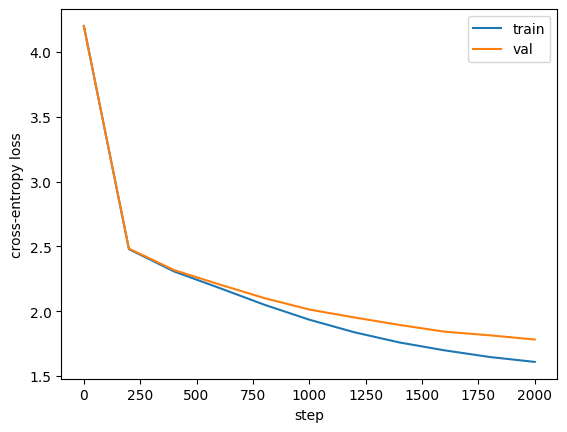

In [10]:
history = result['history']
steps = [row['step'] for row in history]
plt.plot(steps, [row['train_loss'] for row in history], label='train')
plt.plot(steps, [row['val_loss'] for row in history], label='val')
plt.xlabel('step')
plt.ylabel('cross-entropy loss')
plt.legend()
plt.show()

## 固定 prompt 采样

In [13]:
model = result['model']
tokenizer = result['data'].tokenizer
prompt = 'ROMEO:'
prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
set_seed(42)
model.eval()
generated = model.generate(prompt_ids, 1000, temperature=0.8, top_k=20)
print(tokenizer.decode(generated[0].tolist()))

ROMEO:
Fit that that please the me distred he besty:
Auforer me, and be lapinish call have gone
The much I withines ever to againted with
To behind mean to he the hapt me make not dead.


First ORIOLANENCE:
He wilt we as gace thee? worther thee more mine
I have all out to mind the this the milence
To the mind at tongre we bod prisopereingt
Leavy son hearts I haxe god so.

Mettern thee she revolly the paw a amoved bovours,
And death as me honce a can beateds,
I to much make advanse, and whith thine death
This guildess ube he thou man'st a as syrund
To this with all onds not allard.


QUEEN SLIZABETH:
No, I shall I can god and his doubtager
The true the since up, and all leaven's will deept.

Come, all he hast me hath I speech world falsh, not
Fairss is tongue of he ends dine dissue
on licks a purfide myself out are werigue;
But tive he did in his not of not shall more.

AUTOLYCUS:
Have hoter, come it country eyess,
And broth charge have thanks imers.

Stame hold it hence, and water, sir

## Checkpoint 恢复验证

不仅确认文件存在，还重新构造模型与 optimizer，并比较相同输入下的 logits。

In [12]:
checkpoint_path = Path(result['checkpoint'])
restored_model, checkpoint, restored_optimizer = load_checkpoint(checkpoint_path, device)
restored_model.eval()
with torch.no_grad():
    original_logits, _ = model(prompt_ids)
    restored_logits, _ = restored_model(prompt_ids)
torch.testing.assert_close(original_logits, restored_logits)
print('checkpoint restored:', checkpoint_path)
print('saved step:', checkpoint['step'])
print('optimizer state entries:', len(restored_optimizer.state))

checkpoint restored: /content/03-nanogpt/runs/baseline/checkpoint.pt
saved step: 2000
optimizer state entries: 52


## 实验后记录

- 固定 batch loss 是否明显下降？
- baseline 的最低 val loss 是多少？
- train/val gap 从什么时候出现？
- 生成文本先学会了哪些结构？
- GPU 型号、训练时间和最大显存是多少？
- 下一次实验只改变哪个变量？